<a href="https://colab.research.google.com/github/amy165/Brazilian-E-Commerce-Public-Dataset-by-Olist/blob/main/DS/E-Commerce-Customer-Segmentation-KMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
orders_df=pd.read_csv('olist_orders_dataset.csv')
customers_df=pd.read_csv('olist_customers_dataset.csv')
##geolocation_df=pd.read_csv('olist_geolocation_dataset.csv')
order_items_df=pd.read_csv('olist_order_items_dataset.csv')
payments_df=pd.read_csv('olist_order_payments_dataset.csv')
reviews_df=pd.read_csv('olist_order_reviews_dataset.csv')
##products_df=pd.read_csv('olist_products_dataset.csv')
##sellers_df=pd.read_csv('olist_sellers_dataset.csv')
##product_cat_nametrans_df=pd.read_csv('product_category_name_translation.csv')

In [3]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [5]:
orders_df.duplicated()
hay_duplicados = orders_df['customer_id'].duplicated().any()
print(f"¿Hay duplicados? {hay_duplicados}")  # True

¿Hay duplicados? False


In [6]:
customers_df['customer_state'].value_counts()
customers_df['customer_state'].nunique()

27

In [7]:
customers_df['customer_state'] = customers_df['customer_state'].str.strip()
customers_df['customer_state'] = customers_df['customer_state'].str.upper()
customers_df['customer_state'].nunique()

27

In [8]:
full_df=orders_df.copy()
full_df=pd.merge(full_df, customers_df, on='customer_id', how='left')
full_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [9]:
print("Duplicates in orders_df['order_id'] : "+ str(orders_df['order_id'].duplicated().any()))
print("Duplicates in customers_df['customer_id'] : "+ str(customers_df['customer_id'].duplicated().any()))
print("Duplicates in customers_df['customer_unique_id'] : "+ str(customers_df['customer_unique_id'].duplicated().any()))
##print("Duplicates in sellers_df['seller_id'] : "+ str(sellers_df['seller_id'].duplicated().any()))
##print("Duplicates in products_df['product_id'] : "+ str(products_df['product_id'].duplicated().any()))

Duplicates in orders_df['order_id'] : False
Duplicates in customers_df['customer_id'] : False
Duplicates in customers_df['customer_unique_id'] : True


In [10]:
full_df=full_df.drop(['customer_zip_code_prefix','customer_city'], axis=1)

In [11]:
full_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,SP


In [12]:
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [13]:
order_items_df['order_id'].value_counts().head(10)

,count
order_id,
8272b63d03f5f79c56e9e4120aec44ef,21
1b15974a0141d54e36626dca3fdc731a,20
ab14fdcfbe524636d65ee38360e22ce8,20
9ef13efd6949e4573a18964dd1bbe7f5,15
428a2f660dc84138d969ccd69a0ab6d5,15
9bdc4d4c71aa1de4606060929dee888c,14
73c8ab38f07dc94389065f7eba4f297a,14
37ee401157a3a0b28c9c6d0ed8c3b24b,13
2c2a19b5703863c908512d135aa6accc,12


In [14]:
temp_order_items_df=order_items_df.groupby('order_id').agg(
       Num_Products=('order_item_id', 'count'),
       total_price=('price', 'sum'),
       total_freight=('freight_value', 'sum'),
).reset_index()
temp = temp_order_items_df[temp_order_items_df['Num_Products'] > 1]
temp

,order_id,Num_Products,total_price,total_freight
13,0008288aa423d2a3f00fcb17cd7d8719,2,99.80,26.74
31,00143d0f86d6fbd9f9b38ab440ac16f5,3,63.99,45.30
39,001ab0a7578dd66cd4b0a71f5b6e1e41,3,74.67,52.89
43,001d8f0e34a38c37f7dba2a37d4eba8b,2,37.98,15.56
69,002c9def9c9b951b1bec6d50753c9891,2,156.00,17.80
...,...,...,...,...
98603,ffd84ab39cd5e873d8dba24342e65c01,2,49.80,15.56
98626,ffe4b41e99d39f0b837a239110260530,2,38.00,31.58
98637,ffecd5a79a0084f6a592288c67e3c298,3,65.70,47.37
98654,fff8287bbae429a99bb7e8c21d151c41,2,360.00,96.28


In [15]:
full_df=pd.merge(full_df, temp_order_items_df, on='order_id', how='left')
full_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,Num_Products,total_price,total_freight
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,SP,1.0,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,BA,1.0,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,GO,1.0,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,RN,1.0,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,SP,1.0,19.90,8.72


In [16]:
payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [17]:
temp_payments=payments_df.groupby('order_id').agg(
    Total_Payed=('payment_value','sum'),
    max_installments=('payment_installments', 'max'),
    Num_Paym=('payment_value','count')
).reset_index()
main_payment = payments_df.loc[
    payments_df.groupby('order_id')['payment_value'].idxmax()
][['order_id', 'payment_type']]

temp_payments=pd.merge(temp_payments,main_payment,on='order_id', how='left' )
temp_payments = temp_payments.rename(columns={'payment_type': 'main_payment_type'})
temp_payments.head()

,order_id,Total_Payed,max_installments,Num_Paym,main_payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1,credit_card


In [18]:
full_df=pd.merge(full_df, temp_payments, on='order_id', how='left')
full_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,Num_Products,total_price,total_freight,Total_Payed,max_installments,Num_Paym,main_payment_type
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,SP,1.0,29.99,8.72,38.71,1.0,3.0,voucher
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,BA,1.0,118.70,22.76,141.46,1.0,1.0,boleto
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,GO,1.0,159.90,19.22,179.12,3.0,1.0,credit_card
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,RN,1.0,45.00,27.20,72.20,1.0,1.0,credit_card
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,SP,1.0,19.90,8.72,28.62,1.0,1.0,credit_card


In [19]:
reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [20]:
reviews_df['order_id'].value_counts().value_counts()
## hay ordenes con mas de  review posiblemente porque dio uno cuando no habia llegado y otro al llegar el producto. vamos a quedarnos con el avg de los review y con el last review

,count
count,
1,98126
2,543
3,4


In [21]:
temp_reviews = reviews_df.sort_values('review_creation_date').groupby('order_id').agg(
    last_review_score=('review_score', 'last'),
    avg_review_score=('review_score', 'mean'),
    num_reviews=('review_score', 'count')
).reset_index()

temp_reviews.head()

,order_id,last_review_score,avg_review_score,num_reviews
0,00010242fe8c5a6d1ba2dd792cb16214,5,5.0,1
1,00018f77f2f0320c557190d7a144bdd3,4,4.0,1
2,000229ec398224ef6ca0657da4fc703e,5,5.0,1
3,00024acbcdf0a6daa1e931b038114c75,4,4.0,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,5,5.0,1


In [22]:
full_df=pd.merge(full_df, temp_reviews, on='order_id', how='left')

full_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_state', 'Num_Products', 'total_price',
       'total_freight', 'Total_Payed', 'max_installments', 'Num_Paym',
       'main_payment_type', 'last_review_score', 'avg_review_score',
       'num_reviews'],
      dtype='object')

In [23]:
full_df.head(  )

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,Num_Products,total_price,total_freight,Total_Payed,max_installments,Num_Paym,main_payment_type,last_review_score,avg_review_score,num_reviews
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,SP,1.0,29.99,8.72,38.71,1.0,3.0,voucher,4.0,4.0,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,BA,1.0,118.70,22.76,141.46,1.0,1.0,boleto,4.0,4.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,GO,1.0,159.90,19.22,179.12,3.0,1.0,credit_card,5.0,5.0,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,RN,1.0,45.00,27.20,72.20,1.0,1.0,credit_card,5.0,5.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,SP,1.0,19.90,8.72,28.62,1.0,1.0,credit_card,5.0,5.0,1.0


In [24]:
full_df.to_csv('full_df.csv', index=False)
### making a copy

In [25]:
full_df['delivery_time']=(pd.to_datetime(full_df['order_delivered_customer_date'])-pd.to_datetime(full_df['order_purchase_timestamp'])).dt.days
full_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,...,total_price,total_freight,Total_Payed,max_installments,Num_Paym,main_payment_type,last_review_score,avg_review_score,num_reviews,delivery_time
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,SP,...,29.99,8.72,38.71,1.0,3.0,voucher,4.0,4.0,1.0,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,BA,...,118.70,22.76,141.46,1.0,1.0,boleto,4.0,4.0,1.0,13.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,GO,...,159.90,19.22,179.12,3.0,1.0,credit_card,5.0,5.0,1.0,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,RN,...,45.00,27.20,72.20,1.0,1.0,credit_card,5.0,5.0,1.0,13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,SP,...,19.90,8.72,28.62,1.0,1.0,credit_card,5.0,5.0,1.0,2.0


In [26]:
full_df['delay_time']=(pd.to_datetime(full_df['order_delivered_customer_date'])-pd.to_datetime(full_df['order_estimated_delivery_date'])).dt.days
full_df['is_delayed'] = full_df['delay_time'] > 0

full_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,...,Total_Payed,max_installments,Num_Paym,main_payment_type,last_review_score,avg_review_score,num_reviews,delivery_time,delay_time,is_delayed
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,SP,...,38.71,1.0,3.0,voucher,4.0,4.0,1.0,8.0,-8.0,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,BA,...,141.46,1.0,1.0,boleto,4.0,4.0,1.0,13.0,-6.0,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,GO,...,179.12,3.0,1.0,credit_card,5.0,5.0,1.0,9.0,-18.0,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,RN,...,72.20,1.0,1.0,credit_card,5.0,5.0,1.0,13.0,-13.0,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,SP,...,28.62,1.0,1.0,credit_card,5.0,5.0,1.0,2.0,-10.0,False


In [27]:
full_df['payment_diff']=full_df['Total_Payed']-full_df['total_price']-full_df['total_freight']
full_df['payment_diff_abs'] = full_df['payment_diff'].abs()
full_df['has_payment_issue'] = full_df['payment_diff_abs'] > 1  # ajusta threshold
full_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,...,main_payment_type,last_review_score,avg_review_score,num_reviews,delivery_time,delay_time,is_delayed,payment_diff,payment_diff_abs,has_payment_issue
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,SP,...,voucher,4.0,4.0,1.0,8.0,-8.0,False,1.776357e-15,1.776357e-15,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,BA,...,boleto,4.0,4.0,1.0,13.0,-6.0,False,3.552714e-15,3.552714e-15,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,GO,...,credit_card,5.0,5.0,1.0,9.0,-18.0,False,0.000000e+00,0.000000e+00,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,RN,...,credit_card,5.0,5.0,1.0,13.0,-13.0,False,3.552714e-15,3.552714e-15,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,SP,...,credit_card,5.0,5.0,1.0,2.0,-10.0,False,1.776357e-15,1.776357e-15,False


In [28]:
full_df['is_bad_review'] = full_df['last_review_score'] <= 2
full_df['has_review'] = full_df['last_review_score'].notnull()
full_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,...,avg_review_score,num_reviews,delivery_time,delay_time,is_delayed,payment_diff,payment_diff_abs,has_payment_issue,is_bad_review,has_review
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,SP,...,4.0,1.0,8.0,-8.0,False,1.776357e-15,1.776357e-15,False,False,True
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,BA,...,4.0,1.0,13.0,-6.0,False,3.552714e-15,3.552714e-15,False,False,True
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,GO,...,5.0,1.0,9.0,-18.0,False,0.000000e+00,0.000000e+00,False,False,True
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,RN,...,5.0,1.0,13.0,-13.0,False,3.552714e-15,3.552714e-15,False,False,True
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,SP,...,5.0,1.0,2.0,-10.0,False,1.776357e-15,1.776357e-15,False,False,True


In [29]:
full_df['has_multiple_payments'] = full_df['Num_Paym'] > 1
full_df['order_total_value'] = full_df['total_price'] + full_df['total_freight']
full_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,...,delivery_time,delay_time,is_delayed,payment_diff,payment_diff_abs,has_payment_issue,is_bad_review,has_review,has_multiple_payments,order_total_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,SP,...,8.0,-8.0,False,1.776357e-15,1.776357e-15,False,False,True,True,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,BA,...,13.0,-6.0,False,3.552714e-15,3.552714e-15,False,False,True,False,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,GO,...,9.0,-18.0,False,0.000000e+00,0.000000e+00,False,False,True,False,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,RN,...,13.0,-13.0,False,3.552714e-15,3.552714e-15,False,False,True,False,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,SP,...,2.0,-10.0,False,1.776357e-15,1.776357e-15,False,False,True,False,28.62


<Axes: >

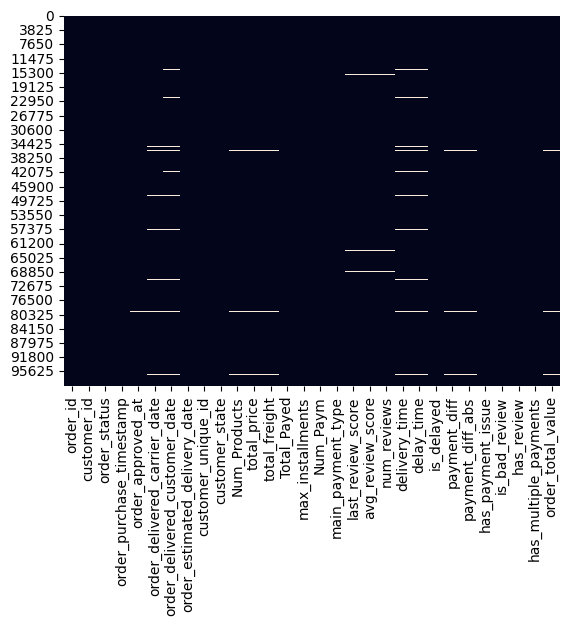

In [30]:
sns.heatmap(full_df.isnull(), cbar=False)

In [31]:
full_df.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0
customer_unique_id,0
customer_state,0


In [32]:
customers_features=full_df.groupby('customer_unique_id').agg(
    Num_orders=('order_id', 'count'),
    Num_products=('Num_Products', 'sum'),
    Total_spend=('order_total_value', 'sum'),
    avg_spend=('order_total_value', 'mean'),
    Max_spend=('order_total_value', 'max'),
    Min_spend=('order_total_value', 'min'),
    Total_payed=('Total_Payed', 'sum'),
    Num_delayed_orders=('is_delayed', 'sum'),
    Num_bad_reviews=('is_bad_review', 'sum'),
    Num_has_review=('has_review', 'sum'),
    Num_has_multiple_payments=('has_multiple_payments', 'sum'),
    Num_has_payment_issue=('has_payment_issue', 'sum'),
    delivery_time=('delivery_time', 'mean')
).reset_index()

customers_features['delay_ratio']=customers_features['Num_delayed_orders']/customers_features['Num_orders']
customers_features['bad_reviews_ratio']=customers_features['Num_bad_reviews']/customers_features['Num_orders']
customers_features['Num_reviews_ratio']=customers_features['Num_has_review']/customers_features['Num_orders']
customers_features['multiple_payments_ratio']=customers_features['Num_has_multiple_payments']/customers_features['Num_orders']
customers_features['payments_issue_ratio']=customers_features['Num_has_payment_issue']/customers_features['Num_orders']

In [33]:
customers_features.head()


,customer_unique_id,Num_orders,Num_products,Total_spend,avg_spend,Max_spend,Min_spend,Total_payed,Num_delayed_orders,Num_bad_reviews,Num_has_review,Num_has_multiple_payments,Num_has_payment_issue,delivery_time,delay_ratio,bad_reviews_ratio,Num_reviews_ratio,multiple_payments_ratio,payments_issue_ratio
0,0000366f3b9a7992bf8c76cfdf3221e2,1,1.0,141.90,141.90,141.90,141.90,141.90,0,0,1,0,0,6.0,0.0,0.0,1.0,0.0,0.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,1.0,27.19,27.19,27.19,27.19,27.19,0,0,1,0,0,3.0,0.0,0.0,1.0,0.0,0.0
2,0000f46a3911fa3c0805444483337064,1,1.0,86.22,86.22,86.22,86.22,86.22,0,0,1,0,0,25.0,0.0,0.0,1.0,0.0,0.0
3,0000f6ccb0745a6a4b88665a16c9f078,1,1.0,43.62,43.62,43.62,43.62,43.62,0,0,1,0,0,20.0,0.0,0.0,1.0,0.0,0.0
4,0004aac84e0df4da2b147fca70cf8255,1,1.0,196.89,196.89,196.89,196.89,196.89,0,0,1,0,0,13.0,0.0,0.0,1.0,0.0,0.0


In [34]:
customers_features.describe()

,Num_orders,Num_products,Total_spend,avg_spend,Max_spend,Min_spend,Total_payed,Num_delayed_orders,Num_bad_reviews,Num_has_review,Num_has_multiple_payments,Num_has_payment_issue,delivery_time,delay_ratio,bad_reviews_ratio,Num_reviews_ratio,multiple_payments_ratio,payments_issue_ratio
count,96096.000000,96096.000000,96096.000000,95420.000000,95420.000000,95420.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,93356.000000,96096.00000,96096.000000,96096.000000,96096.000000,96096.000000
mean,1.034809,1.172265,164.872141,161.044770,162.551934,159.590734,166.592492,0.068005,0.150839,1.026817,0.030813,0.002602,12.103324,0.06610,0.145982,0.992339,0.029554,0.002543
std,0.214384,0.627071,227.938658,221.191784,222.906636,220.726778,231.428332,0.253280,0.365119,0.230733,0.175974,0.050939,9.551802,0.24699,0.351487,0.086586,0.168342,0.050128
min,1.000000,0.000000,0.000000,9.590000,9.590000,9.590000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,62.390000,62.410000,62.667500,61.400000,63.120000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.00000,0.000000,1.000000,0.000000,0.000000
50%,1.000000,1.000000,107.270000,105.770000,106.575000,104.370000,108.000000,0.000000,0.000000,1.000000,0.000000,0.000000,10.000000,0.00000,0.000000,1.000000,0.000000,0.000000
75%,1.000000,1.000000,182.237500,177.122500,178.590000,175.560000,183.530000,0.000000,0.000000,1.000000,0.000000,0.000000,15.000000,0.00000,0.000000,1.000000,0.000000,0.000000
max,17.000000,24.000000,13664.080000,13664.080000,13664.080000,13664.080000,13664.080000,3.000000,3.000000,17.000000,3.000000,1.000000,209.000000,1.00000,1.000000,1.000000,1.000000,1.000000


In [35]:
customers_features.isnull().sum()

,0
customer_unique_id,0
Num_orders,0
Num_products,0
Total_spend,0
avg_spend,676
Max_spend,676
Min_spend,676
Total_payed,0
Num_delayed_orders,0
Num_bad_reviews,0


In [36]:
customers_features[['avg_spend','Max_spend','Min_spend']] = customers_features[['avg_spend','Max_spend','Min_spend']].fillna(0)

In [37]:
customers_features['delivery_time'] = customers_features['delivery_time'].fillna(-1)

In [38]:
customers_features.isnull().sum()

,0
customer_unique_id,0
Num_orders,0
Num_products,0
Total_spend,0
avg_spend,0
Max_spend,0
Min_spend,0
Total_payed,0
Num_delayed_orders,0
Num_bad_reviews,0


In [39]:
customers_features.describe()

,Num_orders,Num_products,Total_spend,avg_spend,Max_spend,Min_spend,Total_payed,Num_delayed_orders,Num_bad_reviews,Num_has_review,Num_has_multiple_payments,Num_has_payment_issue,delivery_time,delay_ratio,bad_reviews_ratio,Num_reviews_ratio,multiple_payments_ratio,payments_issue_ratio
count,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.00000,96096.000000,96096.000000,96096.000000,96096.000000
mean,1.034809,1.172265,164.872141,159.911879,161.408441,158.468072,166.592492,0.068005,0.150839,1.026817,0.030813,0.002602,11.729707,0.06610,0.145982,0.992339,0.029554,0.002543
std,0.214384,0.627071,227.938658,220.822986,222.536298,220.353092,231.428332,0.253280,0.365119,0.230733,0.175974,0.050939,9.663929,0.24699,0.351487,0.086586,0.168342,0.050128
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,62.390000,61.730000,61.877500,60.537500,63.120000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.00000,0.000000,1.000000,0.000000,0.000000
50%,1.000000,1.000000,107.270000,105.220000,105.870000,103.550000,108.000000,0.000000,0.000000,1.000000,0.000000,0.000000,10.000000,0.00000,0.000000,1.000000,0.000000,0.000000
75%,1.000000,1.000000,182.237500,176.322500,177.990000,174.820000,183.530000,0.000000,0.000000,1.000000,0.000000,0.000000,15.000000,0.00000,0.000000,1.000000,0.000000,0.000000
max,17.000000,24.000000,13664.080000,13664.080000,13664.080000,13664.080000,13664.080000,3.000000,3.000000,17.000000,3.000000,1.000000,209.000000,1.00000,1.000000,1.000000,1.000000,1.000000


array([[<Axes: title={'center': 'Num_orders'}>,
        <Axes: title={'center': 'Num_products'}>,
        <Axes: title={'center': 'Total_spend'}>,
        <Axes: title={'center': 'avg_spend'}>],
       [<Axes: title={'center': 'Max_spend'}>,
        <Axes: title={'center': 'Min_spend'}>,
        <Axes: title={'center': 'Total_payed'}>,
        <Axes: title={'center': 'Num_delayed_orders'}>],
       [<Axes: title={'center': 'Num_bad_reviews'}>,
        <Axes: title={'center': 'Num_has_review'}>,
        <Axes: title={'center': 'Num_has_multiple_payments'}>,
        <Axes: title={'center': 'Num_has_payment_issue'}>],
       [<Axes: title={'center': 'delivery_time'}>,
        <Axes: title={'center': 'delay_ratio'}>,
        <Axes: title={'center': 'bad_reviews_ratio'}>,
        <Axes: title={'center': 'Num_reviews_ratio'}>],
       [<Axes: title={'center': 'multiple_payments_ratio'}>,
        <Axes: title={'center': 'payments_issue_ratio'}>, <Axes: >,
        <Axes: >]], dtype=object)

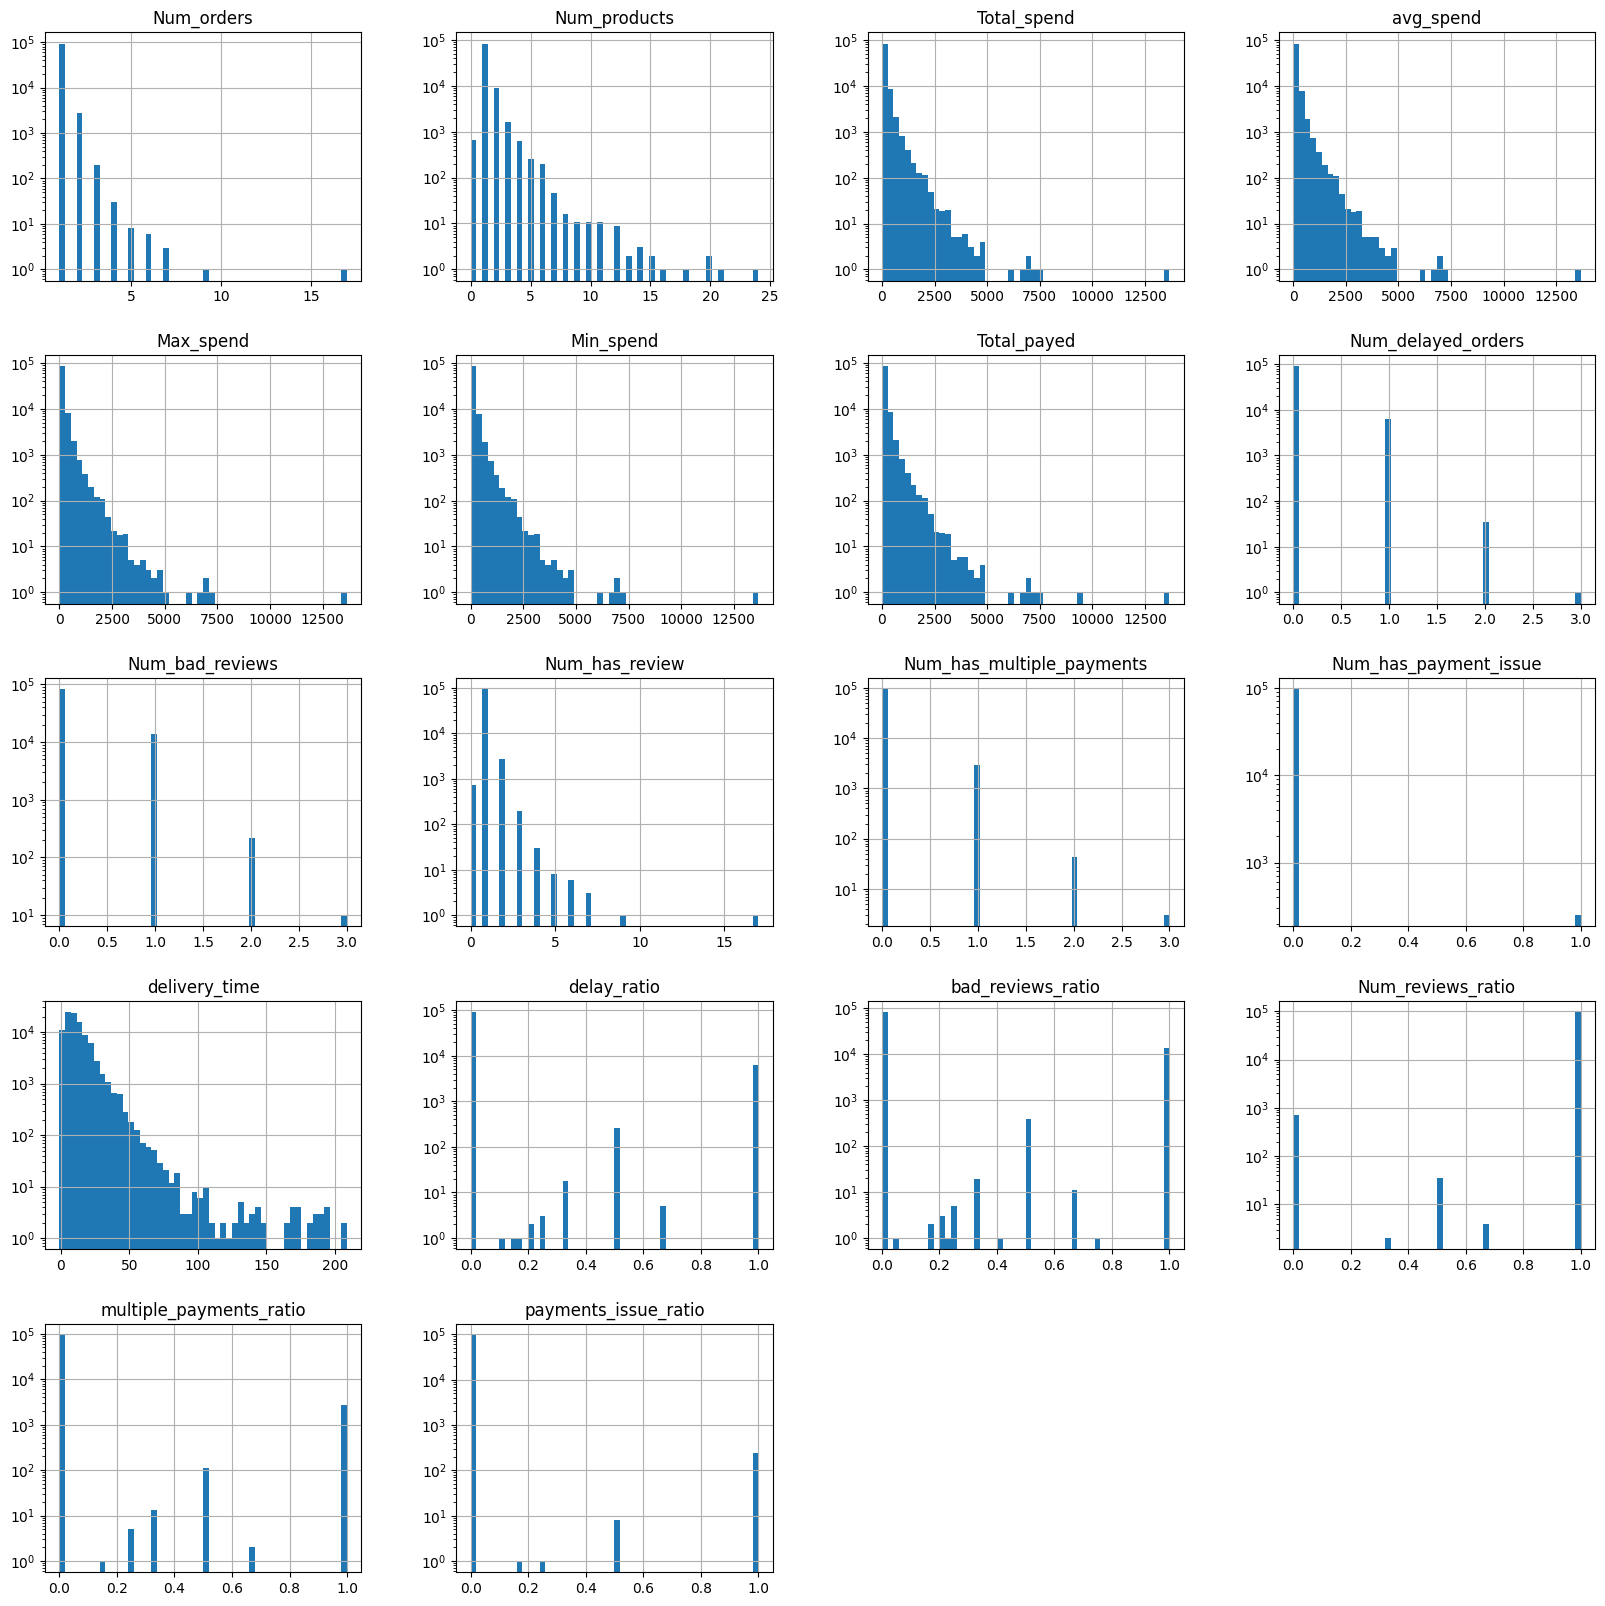

In [40]:
customers_features.hist(bins=50, figsize=(20,20),log=True)

In [41]:
##transformamos con log1p(x) = ln(1 + x) para manejar datos muy sesgados. maneja el 0 bien pues ln(0+1)=0
## en el caso de delivery grandes puede sesgar tambien asi que ponemos 60 para todos los que tienen 60 o mas pues es igual de malo

import numpy as np

# logs
###customers_features_log = customers_features.copy()
customers_features['Total_spend_log'] = np.log1p(customers_features['Total_spend'])
customers_features['avg_spend_log'] = np.log1p(customers_features['avg_spend'])
customers_features['Total_payed_log'] = np.log1p(customers_features['Total_payed'])

# cap delivery
customers_features['delivery_time'] = customers_features['delivery_time'].clip(upper=60)

array([[<Axes: title={'center': 'Num_orders'}>,
        <Axes: title={'center': 'Num_products'}>,
        <Axes: title={'center': 'Total_spend'}>,
        <Axes: title={'center': 'avg_spend'}>,
        <Axes: title={'center': 'Max_spend'}>],
       [<Axes: title={'center': 'Min_spend'}>,
        <Axes: title={'center': 'Total_payed'}>,
        <Axes: title={'center': 'Num_delayed_orders'}>,
        <Axes: title={'center': 'Num_bad_reviews'}>,
        <Axes: title={'center': 'Num_has_review'}>],
       [<Axes: title={'center': 'Num_has_multiple_payments'}>,
        <Axes: title={'center': 'Num_has_payment_issue'}>,
        <Axes: title={'center': 'delivery_time'}>,
        <Axes: title={'center': 'delay_ratio'}>,
        <Axes: title={'center': 'bad_reviews_ratio'}>],
       [<Axes: title={'center': 'Num_reviews_ratio'}>,
        <Axes: title={'center': 'multiple_payments_ratio'}>,
        <Axes: title={'center': 'payments_issue_ratio'}>,
        <Axes: title={'center': 'Total_spend_log

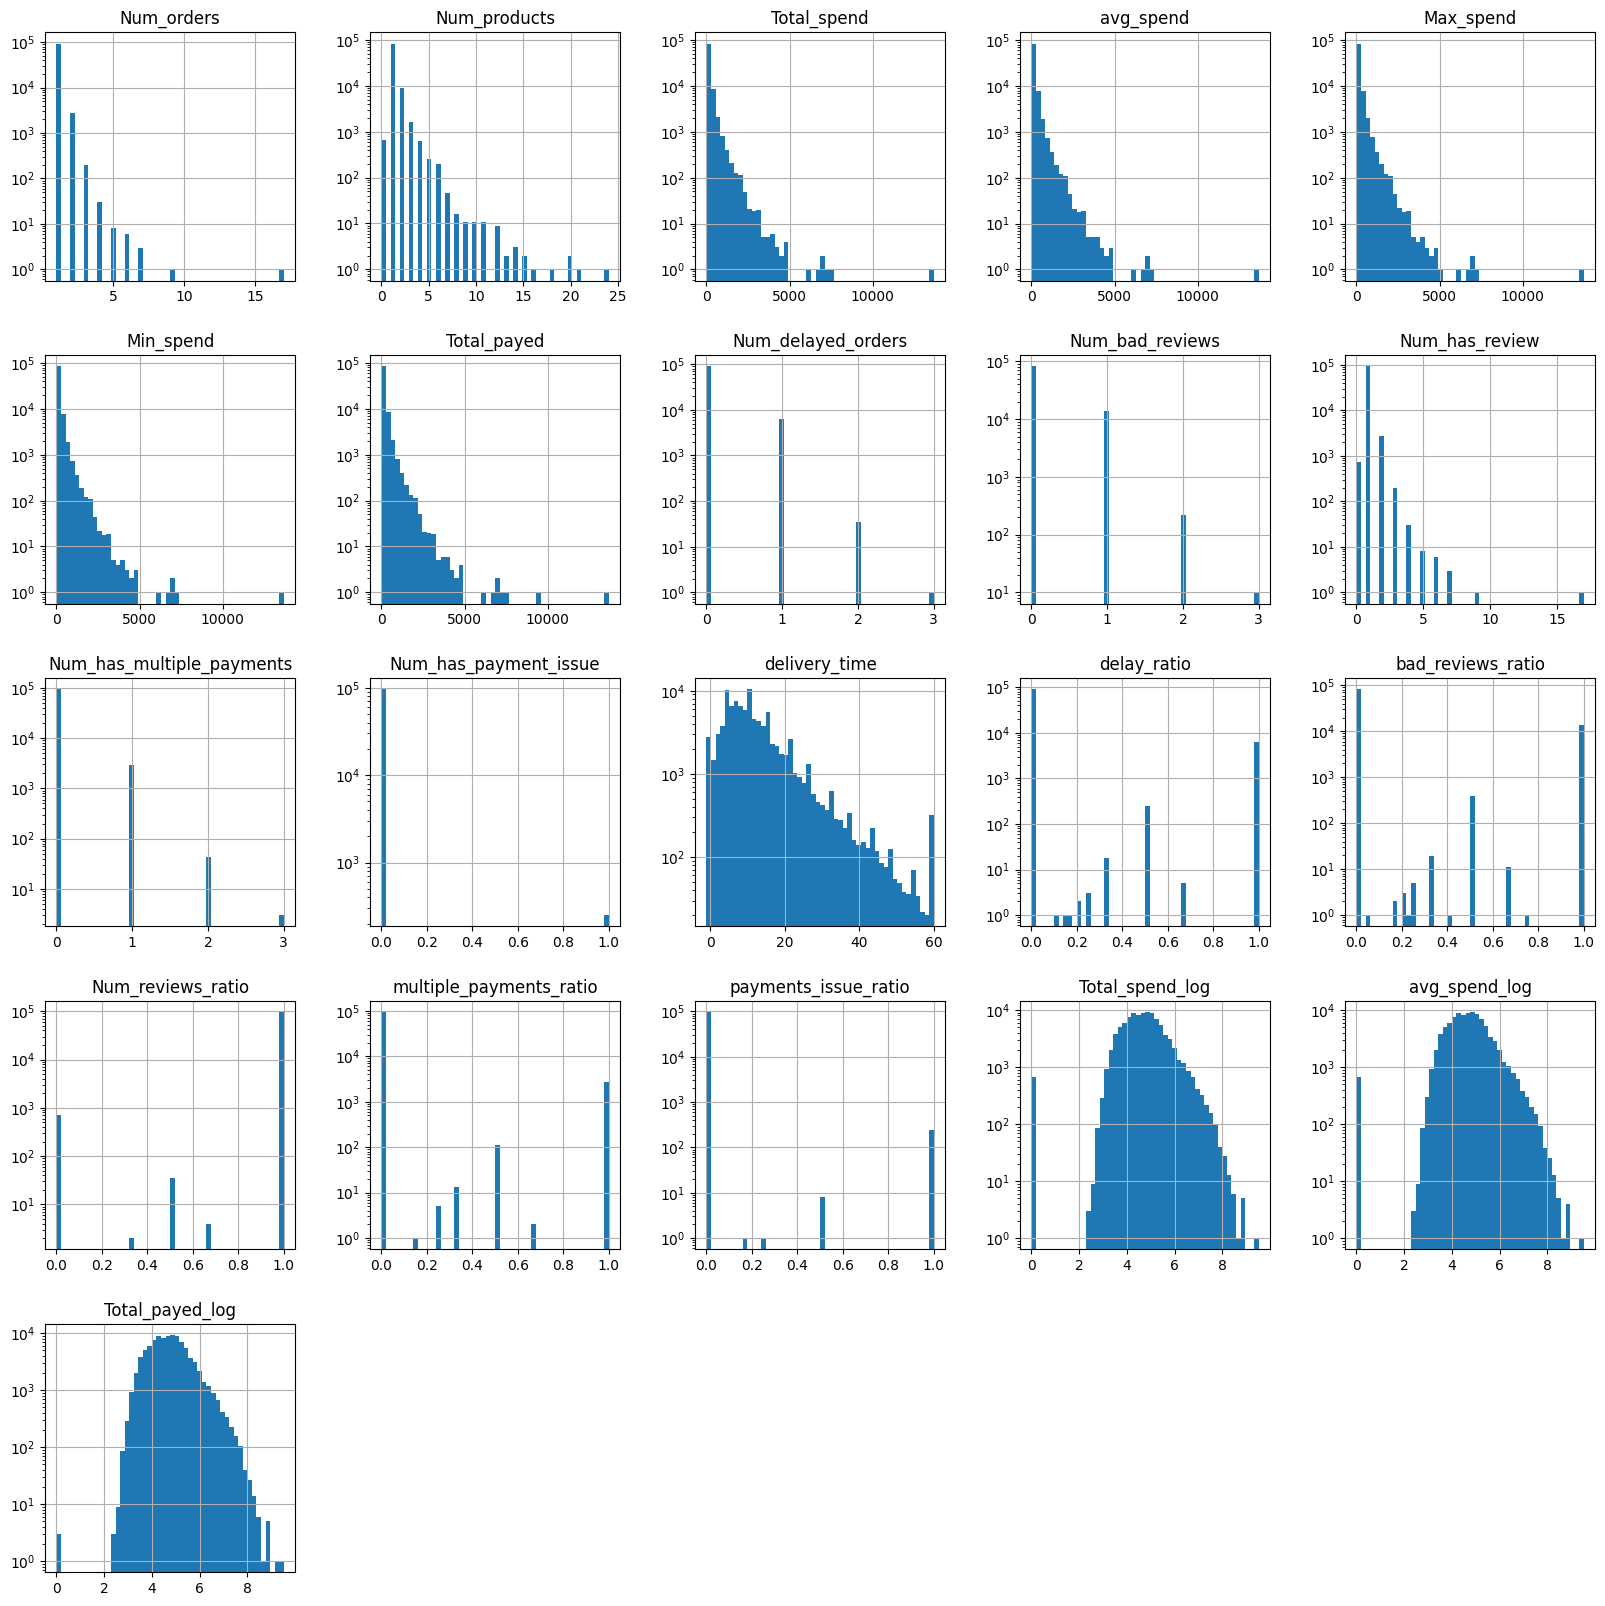

In [42]:
customers_features.hist(bins=50, figsize=(20,20),log=True)

In [43]:
customers_features.columns

Index(['customer_unique_id', 'Num_orders', 'Num_products', 'Total_spend',
       'avg_spend', 'Max_spend', 'Min_spend', 'Total_payed',
       'Num_delayed_orders', 'Num_bad_reviews', 'Num_has_review',
       'Num_has_multiple_payments', 'Num_has_payment_issue', 'delivery_time',
       'delay_ratio', 'bad_reviews_ratio', 'Num_reviews_ratio',
       'multiple_payments_ratio', 'payments_issue_ratio', 'Total_spend_log',
       'avg_spend_log', 'Total_payed_log'],
      dtype='object')

In [44]:
X=customers_features[['Num_orders', 'Num_products',
       'delivery_time',
       'delay_ratio', 'bad_reviews_ratio', 'Num_reviews_ratio',
       'multiple_payments_ratio', 'payments_issue_ratio',
       'avg_spend_log']].copy()
X.head()

,Num_orders,Num_products,delivery_time,delay_ratio,bad_reviews_ratio,Num_reviews_ratio,multiple_payments_ratio,payments_issue_ratio,avg_spend_log
0,1,1.0,6.0,0.0,0.0,1.0,0.0,0.0,4.962145
1,1,1.0,3.0,0.0,0.0,1.0,0.0,0.0,3.338967
2,1,1.0,25.0,0.0,0.0,1.0,0.0,0.0,4.468434
3,1,1.0,20.0,0.0,0.0,1.0,0.0,0.0,3.798182
4,1,1.0,13.0,0.0,0.0,1.0,0.0,0.0,5.287711


<Axes: >

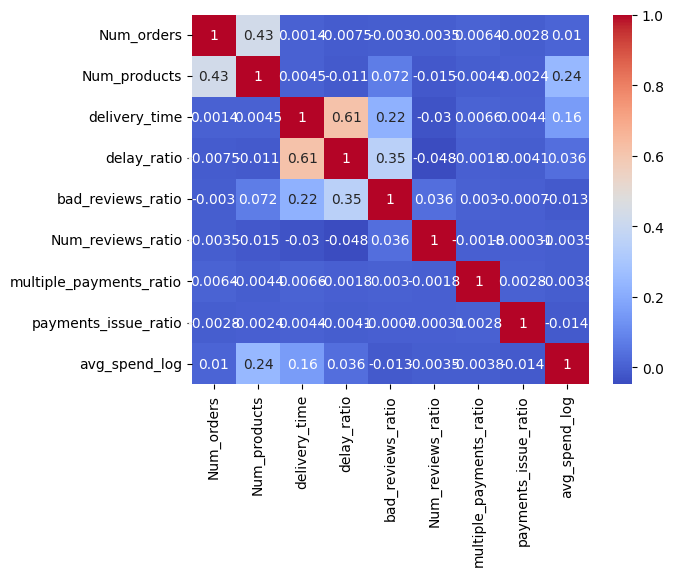

In [45]:
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')


In [46]:
X.isnull().sum()

,0
Num_orders,0
Num_products,0
delivery_time,0
delay_ratio,0
bad_reviews_ratio,0
Num_reviews_ratio,0
multiple_payments_ratio,0
payments_issue_ratio,0
avg_spend_log,0


In [47]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled=pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,Num_orders,Num_products,delivery_time,delay_ratio,bad_reviews_ratio,Num_reviews_ratio,multiple_payments_ratio,payments_issue_ratio,avg_spend_log
0,-0.162368,-0.274715,-0.633439,-0.267622,-0.415329,0.088476,-0.175563,-0.05074,0.321591
1,-0.162368,-0.274715,-0.969952,-0.267622,-0.415329,0.088476,-0.175563,-0.05074,-1.505366
2,-0.162368,-0.274715,1.497811,-0.267622,-0.415329,0.088476,-0.175563,-0.05074,-0.234102
3,-0.162368,-0.274715,0.936956,-0.267622,-0.415329,0.088476,-0.175563,-0.05074,-0.988499
4,-0.162368,-0.274715,0.151758,-0.267622,-0.415329,0.088476,-0.175563,-0.05074,0.688030


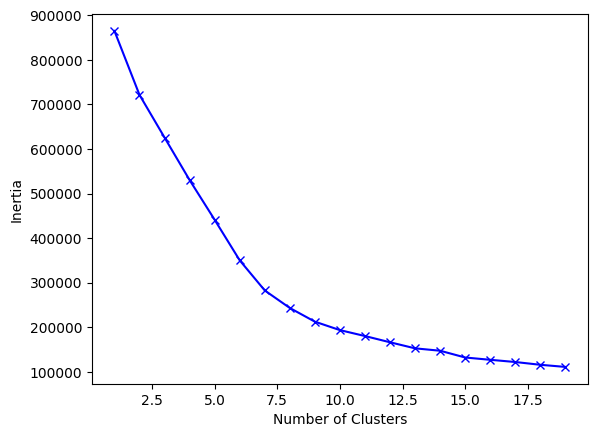

In [48]:
from sklearn.cluster import KMeans
range_values=range(1,20)
scores=[]

for i in range_values:
  kmeans=KMeans(n_clusters=i,random_state=42, n_init=10)
  kmeans.fit(X_scaled)
  scores.append(kmeans.inertia_)

plt.plot(range_values,scores,'bx-')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [49]:
kmeans=KMeans(n_clusters=7,random_state=42, n_init=10)
kmeans.fit_predict(X_scaled)
labels=kmeans.labels_


In [51]:
## revisamos los diferentes clusters

cols_to_view = [
    'Num_orders',
    'Num_products',
    'Total_spend',
    'avg_spend',
    'delivery_time',
    'delay_ratio',
    'bad_reviews_ratio',
    'multiple_payments_ratio',
    'payments_issue_ratio'
]

customers_features['cluster'] = labels

cluster_summary = customers_features.groupby('cluster')[cols_to_view].mean().round(2)
cluster_summary

,Num_orders,Num_products,Total_spend,avg_spend,delivery_time,delay_ratio,bad_reviews_ratio,multiple_payments_ratio,payments_issue_ratio
cluster,,,,,,,,,
0,1.00,1.09,154.79,154.79,10.28,0.00,0.00,0.00,0.0
1,1.00,1.11,110.37,110.37,12.35,0.05,0.14,0.04,1.0
2,1.00,1.11,175.51,175.17,32.23,1.00,0.63,0.00,0.0
3,1.01,1.24,191.22,188.47,14.61,0.20,0.00,0.03,0.0
4,1.00,1.24,176.37,176.37,9.25,0.00,1.00,0.00,0.0
5,2.01,2.89,338.28,193.90,11.46,0.05,0.15,0.02,0.0
6,1.01,1.12,166.61,165.33,11.81,0.06,0.15,1.00,0.0


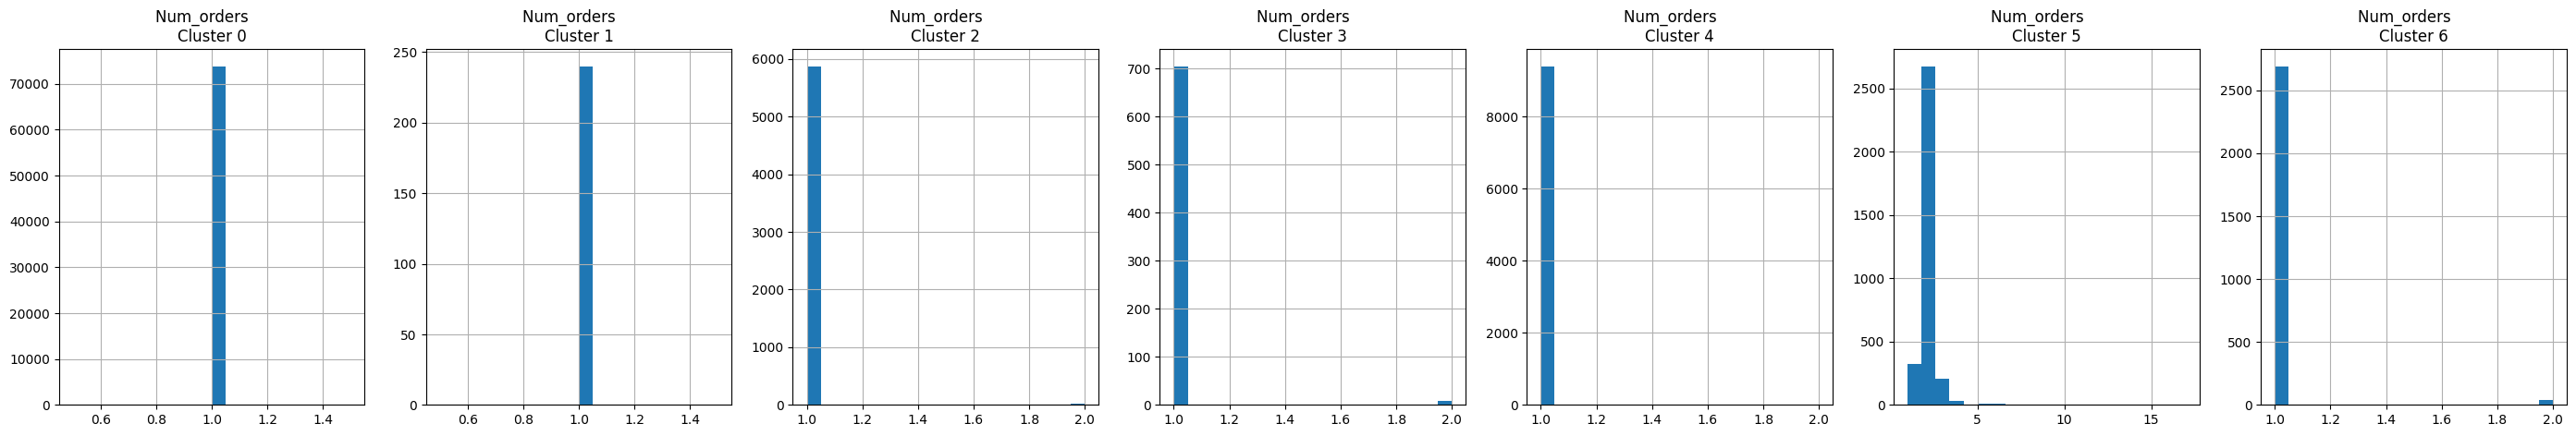

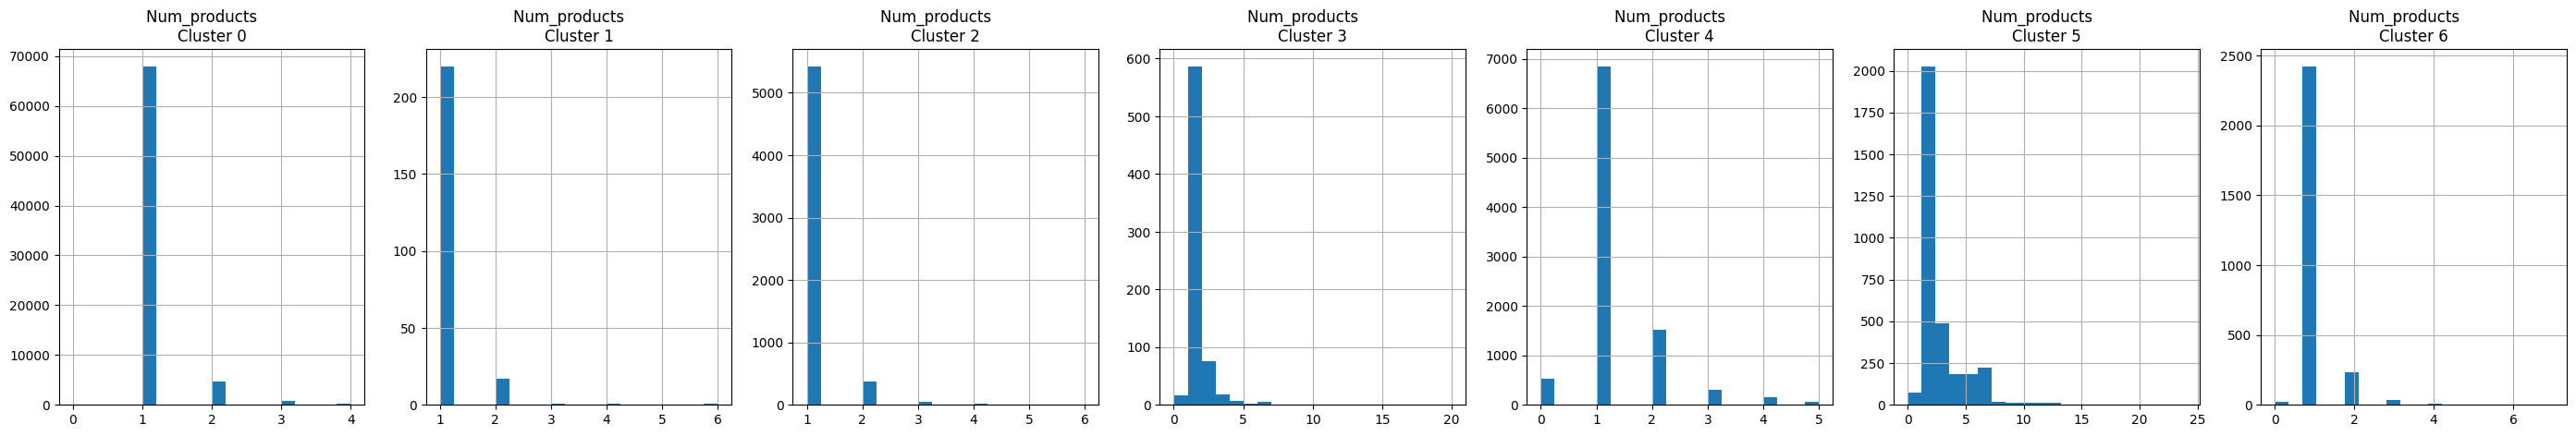

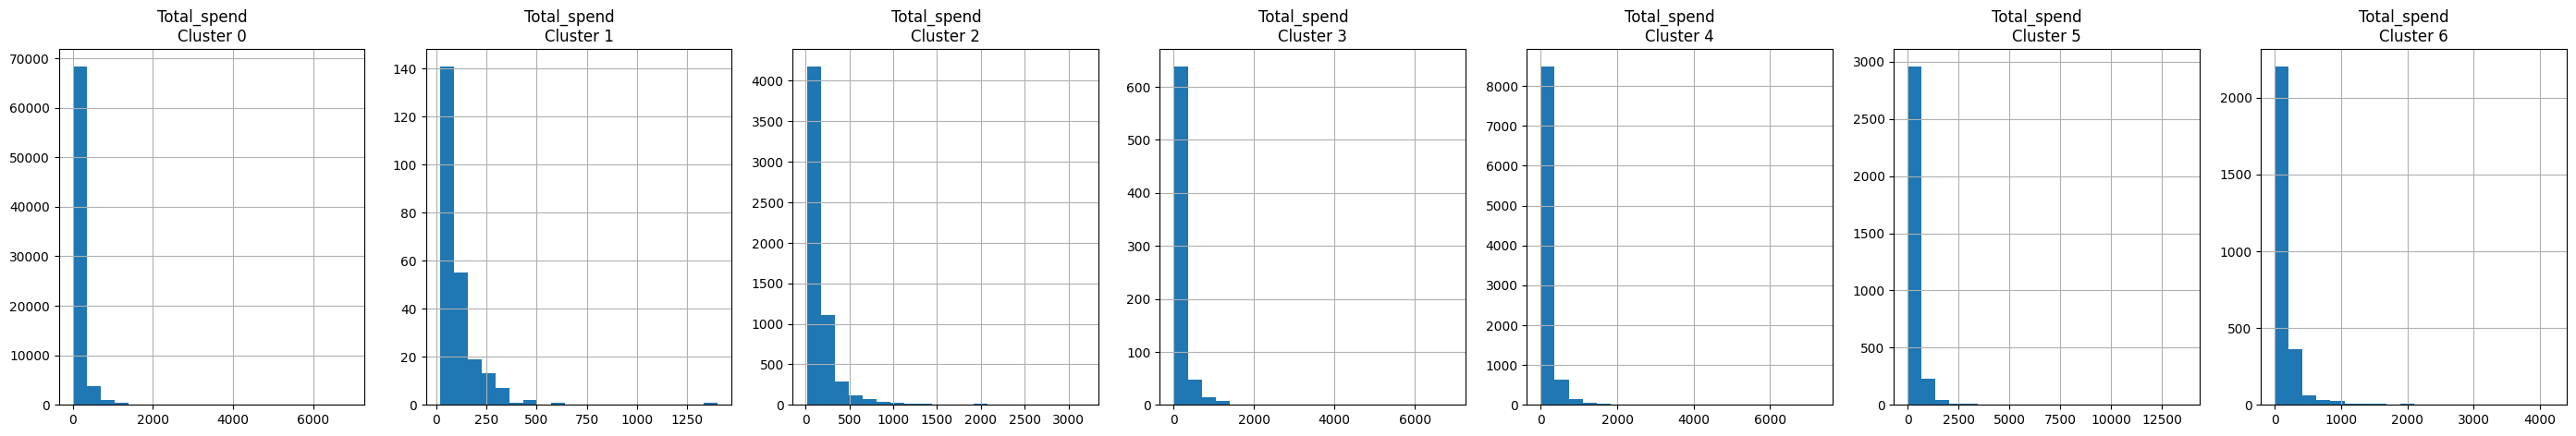

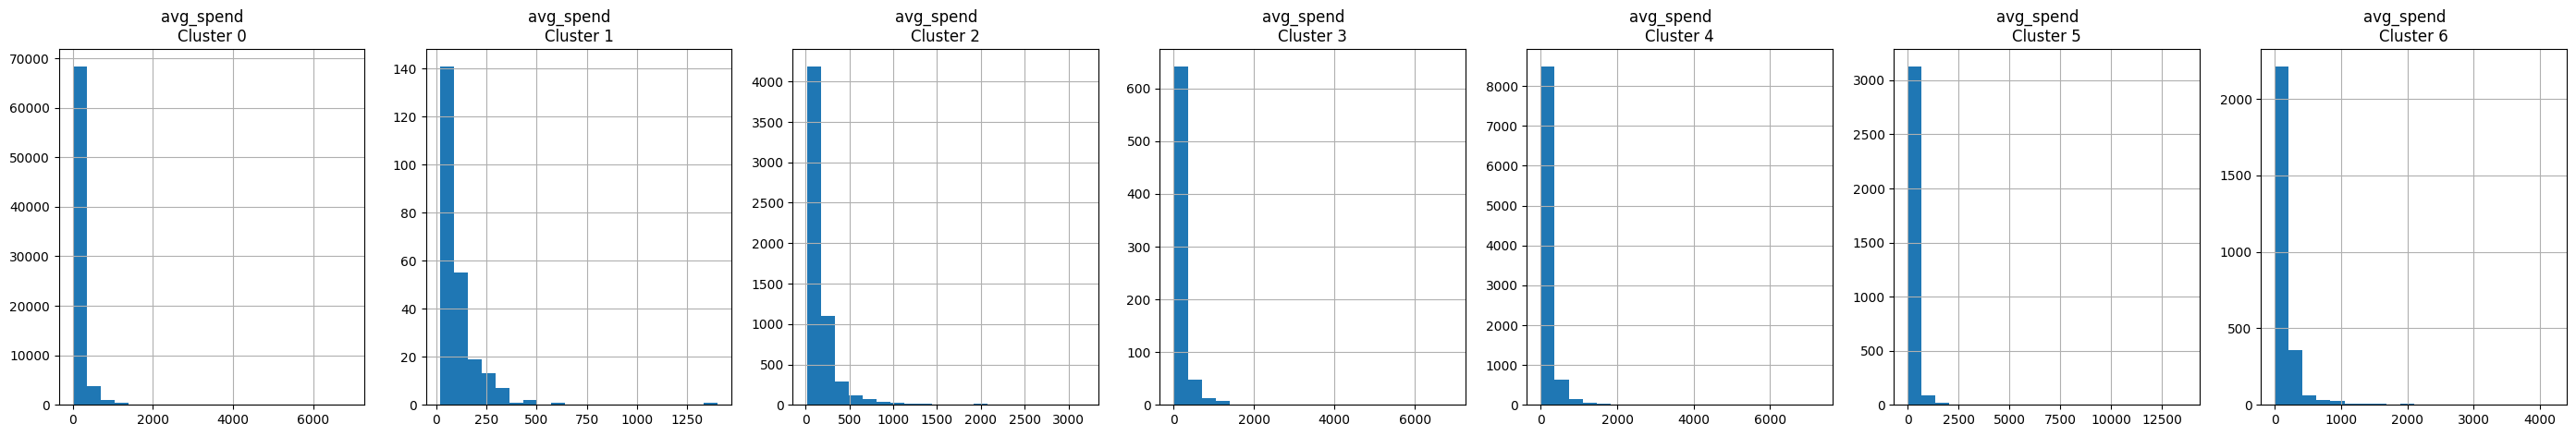

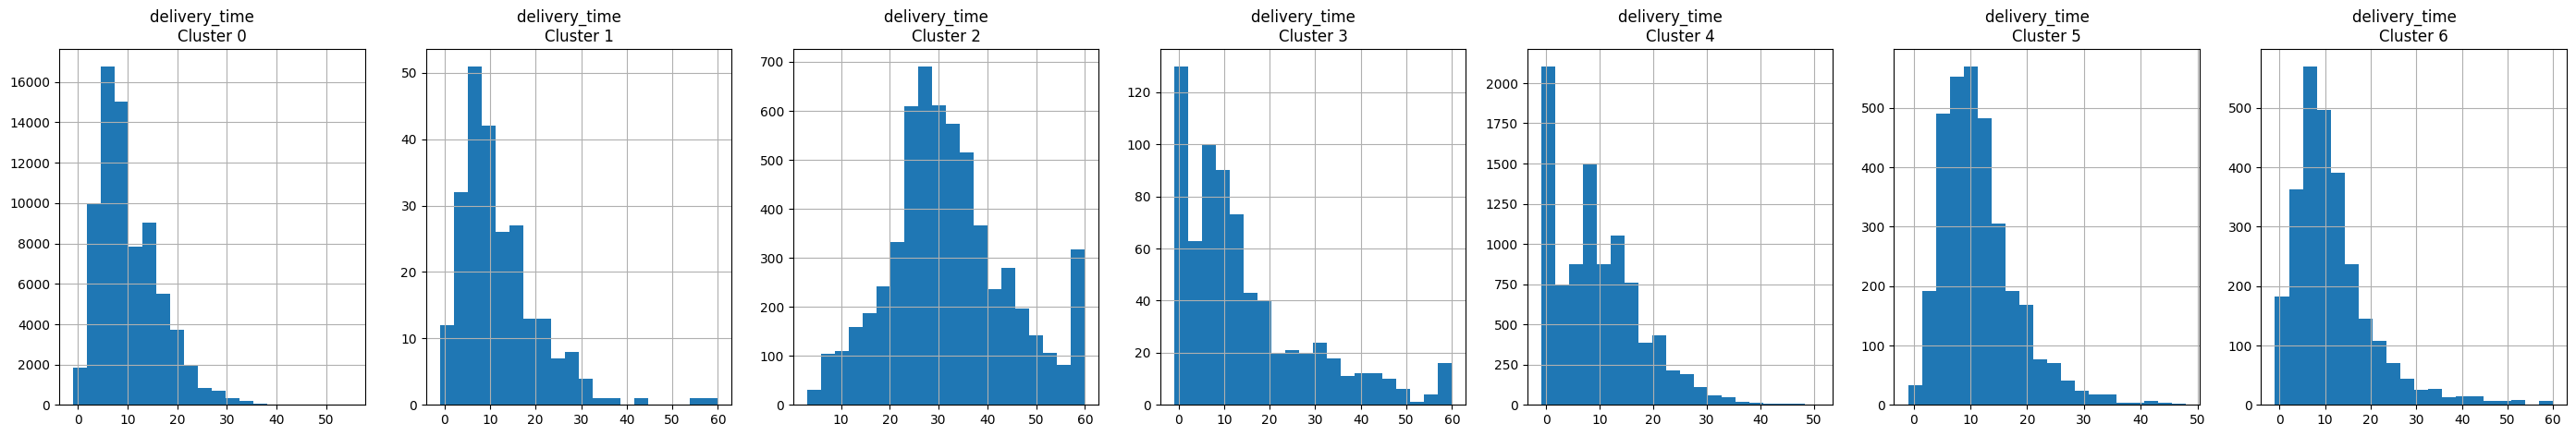

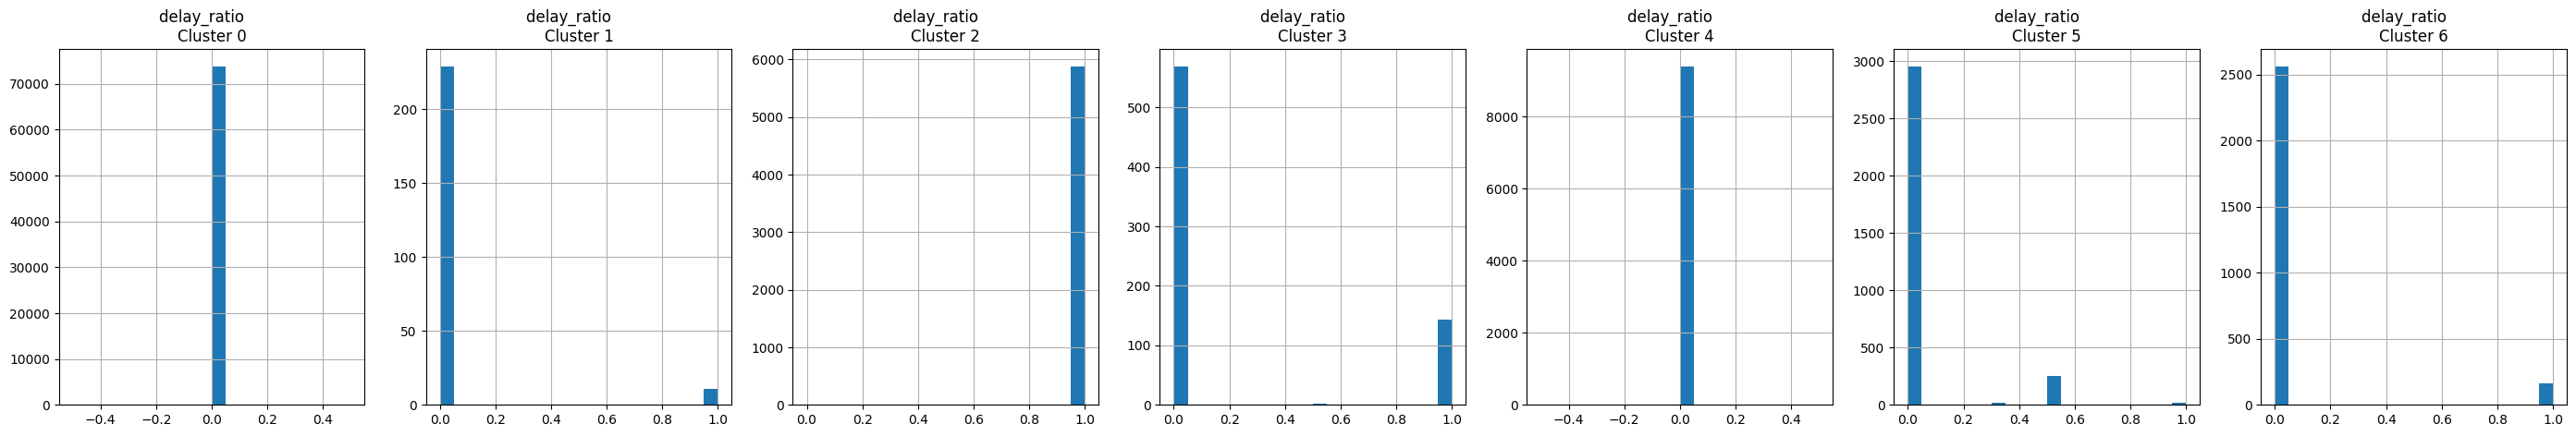

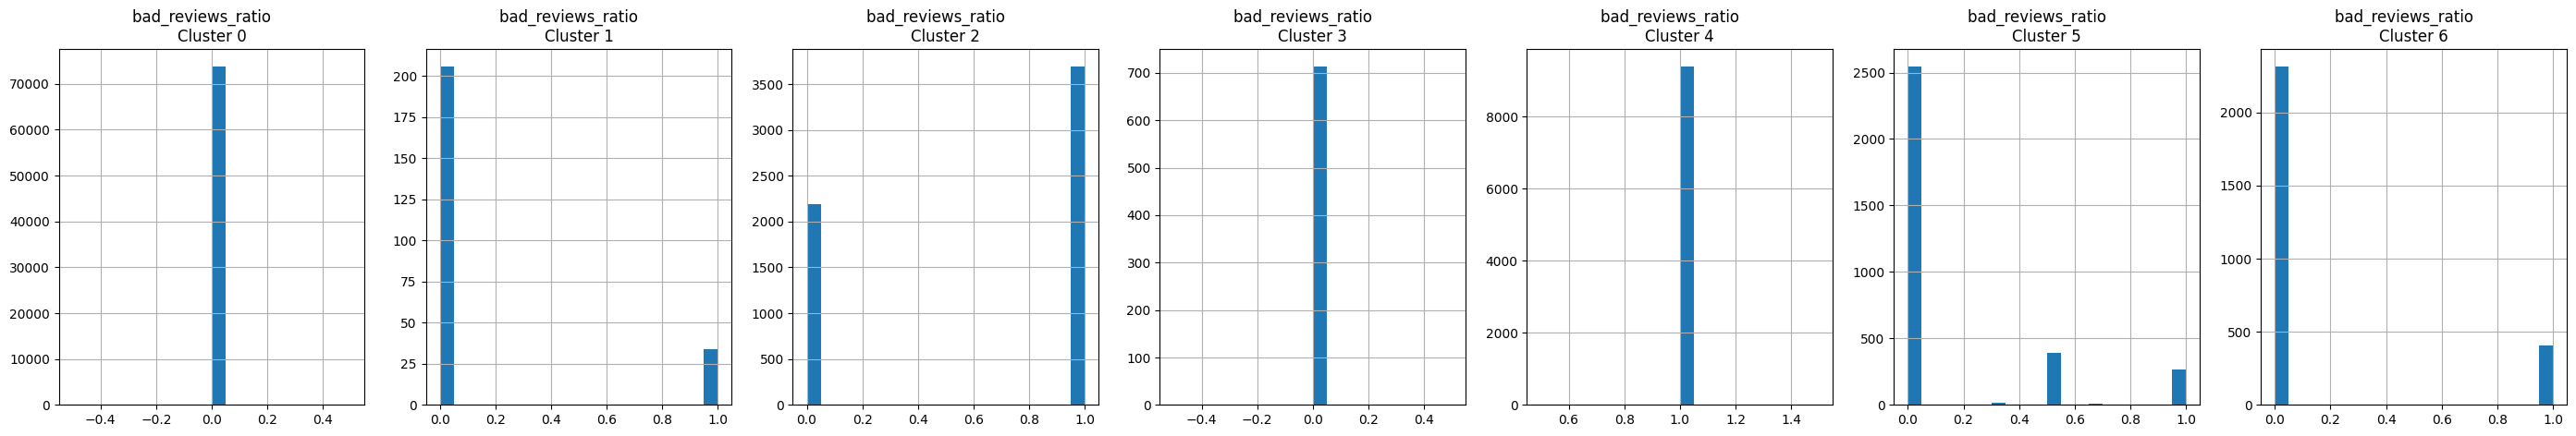

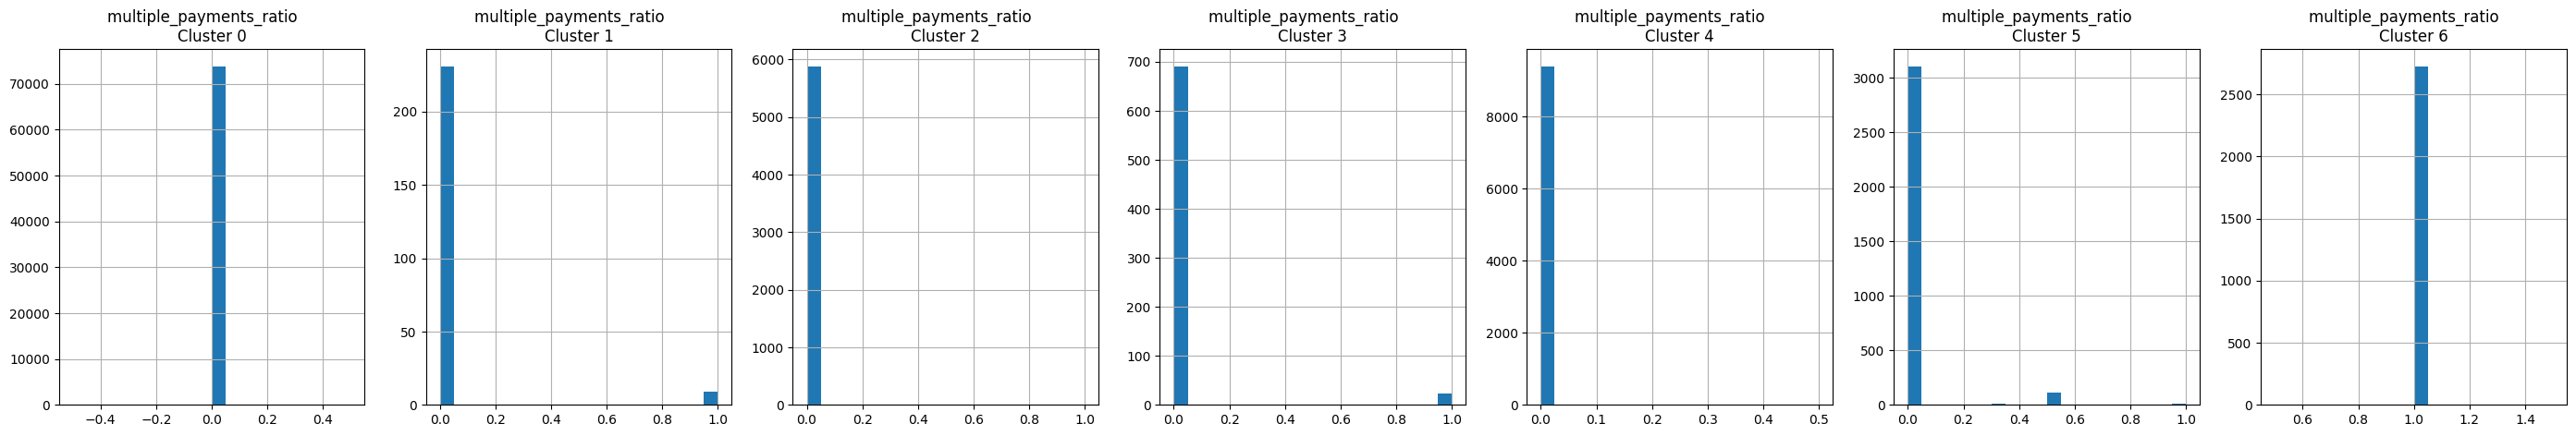

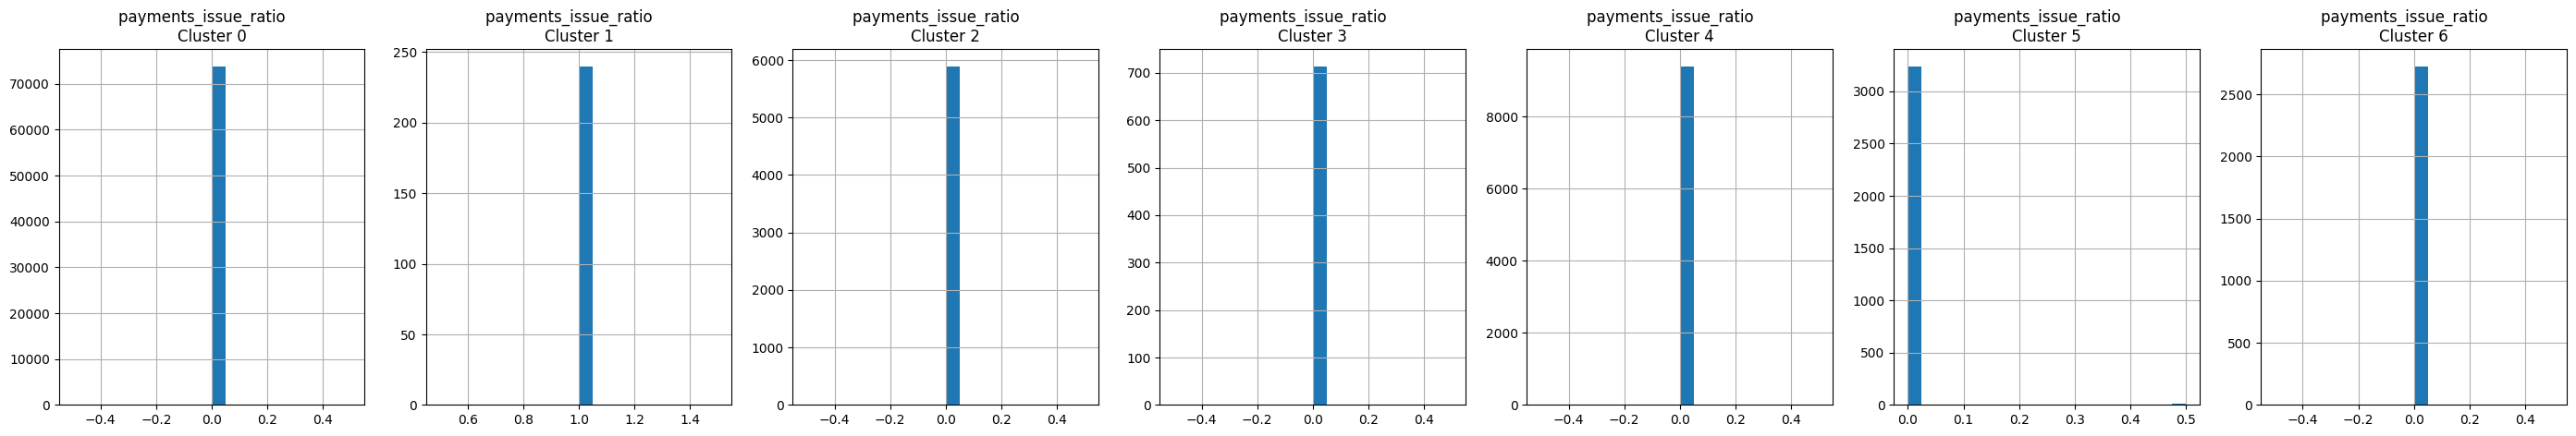

In [56]:
for i in cols_to_view:
    plt.figure(figsize=(35,5))
    for j in range(7):
        plt.subplot(1, 7, j+1)
        cluster = customers_features[customers_features['cluster'] == j]
        cluster[i].hist(bins = 20)
        plt.title('{}    \nCluster {}'.format(i, j))
    plt.show()

In [52]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
principal_comp=pca.fit_transform(X_scaled)
principal_comp

array([[-0.72257897, -0.07683643],
       [-1.22929002, -0.6421505 ],
       [ 0.48363464, -0.43562719],
       ...,
       [-0.21894131, -0.23624826],
       [-0.39200036, -0.14538579],
       [-0.78025976, -0.33401066]])

In [53]:
pca_df=pd.DataFrame(data=principal_comp, columns=['PC1','PC2'])
pca_df

,PC1,PC2
0,-0.722579,-0.076836
1,-1.229290,-0.642151
2,0.483635,-0.435627
3,0.017450,-0.633767
4,-0.183843,-0.023486
...,...,...
96091,1.378961,1.813431
96092,0.821684,-0.489483
96093,-0.218941,-0.236248
96094,-0.392000,-0.145386


In [54]:
pca_df['cluster']=labels
pca_df.head()

,PC1,PC2,cluster
0,-0.722579,-0.076836,0
1,-1.229290,-0.642151,0
2,0.483635,-0.435627,0
3,0.017450,-0.633767,0
4,-0.183843,-0.023486,0


<Axes: xlabel='PC1', ylabel='PC2'>

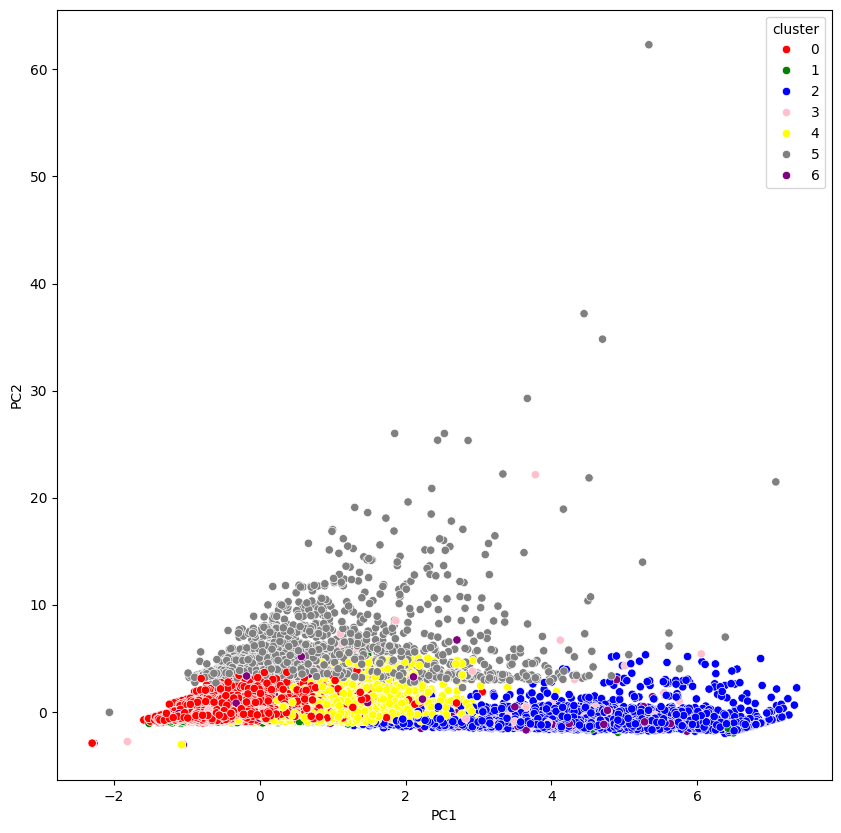

In [55]:
plt.figure(figsize=(10,10))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='cluster',palette=["red", "green", "blue", "pink", "yellow", "gray", "purple"])